<a href="https://colab.research.google.com/github/nyayuchika/rfpp-coursework/blob/main/Tugas_2_RFPP_Nyayu_Chika_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Acquisition

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Dataset_ASR/Training"

In [ ]:
path

'/content/drive/MyDrive/Dataset_ASR/Training'

In [ ]:
import glob
records = glob.glob(path + "/*")
print(len(records))

125


In [ ]:
#cek apakah semua rekaman terbaca
records

['/content/drive/MyDrive/Dataset_ASR/Training/Berhenti 1.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Berhenti 2.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Berhenti 3.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Berhenti 4.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Berhenti 5.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kanan 1.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kanan 2.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kanan 3.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kanan 4.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kanan 5.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kiri 1.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kiri 2.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kiri 3.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kiri 4.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Kiri 5.m4a',
 '/content/drive/MyDrive/Dataset_ASR/Training/Maju 1.m4a',
 '/content/drive/MyDrive/Datase

In [ ]:
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
!pip install ffmpeg-python

In [ ]:
#convert dari m4a ke wav
import ffmpeg
import os

list_records = []
for i in range(len(records)):
  file_m4a = os.path.basename(records[i])
  #konversi .m4a menjadi .wav menggunakan ffmpeg
  process = (
      ffmpeg
      .input(records[i])
      .output('pipe:1', format='wav',acodec='pcm_s16le')
      .run_async(pipe_stdin=True, pipe_stdout=True, pipe_stderr=True, quiet=True)
  )
  file_wav, err = process.communicate()
  list_records.append(file_wav)

In [ ]:
print(len(list_records))

125


In [ ]:
#Ubah menjadi sinyal
import librosa
import io

sinyal_1d = []
sample_rate = []

for i in range(len(list_records)):
  sinyal, sr = librosa.load(io.BytesIO(list_records[i]), sr=16000)
  sinyal_1d.append(sinyal)
  sample_rate.append(sr)

In [ ]:
print(f"Total sinyal 1D yang berhasil dikonversi: {len(sinyal_1d)}")

Total sinyal 1D yang berhasil dikonversi: 125


Membuat visualisasi sinyal 1D


<Figure size 1000x400 with 0 Axes>

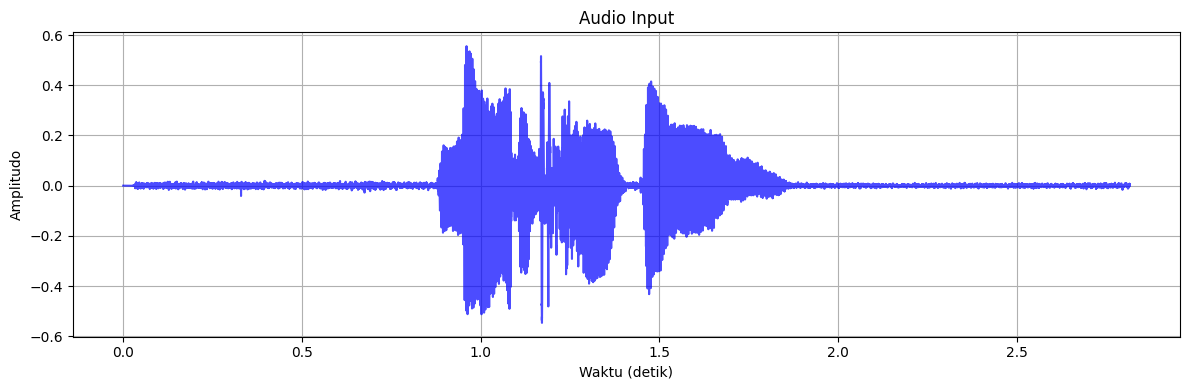

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print("Membuat visualisasi sinyal 1D")

# Plot sinyal 1D
plt.figure(figsize=(10, 4))
time_axis = np.linspace(0, len(sinyal_1d[1]) / sample_rate[1], num=len(sinyal_1d[1]))

plt.figure(figsize=(12, 4)) # Ukuran plot
plt.plot(time_axis, sinyal_1d[1], color='blue', alpha=0.7) # Plot sinyal
plt.title('Audio Input') # Judul
plt.xlabel('Waktu (detik)') # Label sumbu X
plt.ylabel('Amplitudo') # Label sumbu Y
plt.grid(True) # Tampilkan grid
plt.tight_layout() # Atur layout agar rapi
plt.show() # Tampilkan plot

#Preprocessing

In [ ]:
#potong bagian diamnya (trimming)
signal_trimmed = []
for i in range(len(sinyal_1d)):
  #top_db: maksudnya yang di bawah 10db akan dipotong, dianggap sebagai diam
  y_trimmed, index = librosa.effects.trim(sinyal_1d[i], top_db=20)
  signal_trimmed.append(y_trimmed)

In [ ]:
print(len(signal_trimmed))

125


Visualisasi setelah proses trimming


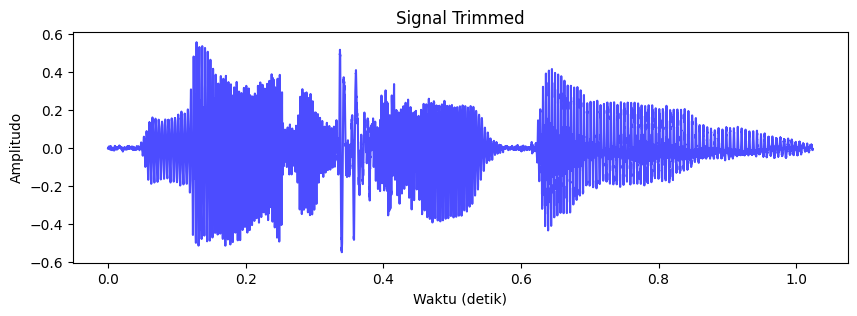

In [ ]:
print("Visualisasi setelah proses trimming")
time = np.linspace(0, len(signal_trimmed[1]) / sr, num=len(signal_trimmed[1]))

plt.figure(figsize=(10, 3)) # Ukuran plot
plt.plot(time, signal_trimmed[1], color='blue', alpha=0.7) # Plot sinyal
plt.title('Signal Trimmed') # Judul
plt.xlabel('Waktu (detik)') # Label sumbu X
plt.ylabel('Amplitudo') # Label sumbu Y
plt.show() # Tampilkan plot

In [ ]:
!pip install noisereduce

In [ ]:
#lakukan noise reduction (hapus suara yang tidak penting/noise)
import noisereduce as nr
signal_clean = []
for i in range(len(signal_trimmed)):
  y_clean = nr.reduce_noise(y=signal_trimmed[i], sr=sample_rate[i])
  signal_clean.append(y_clean)

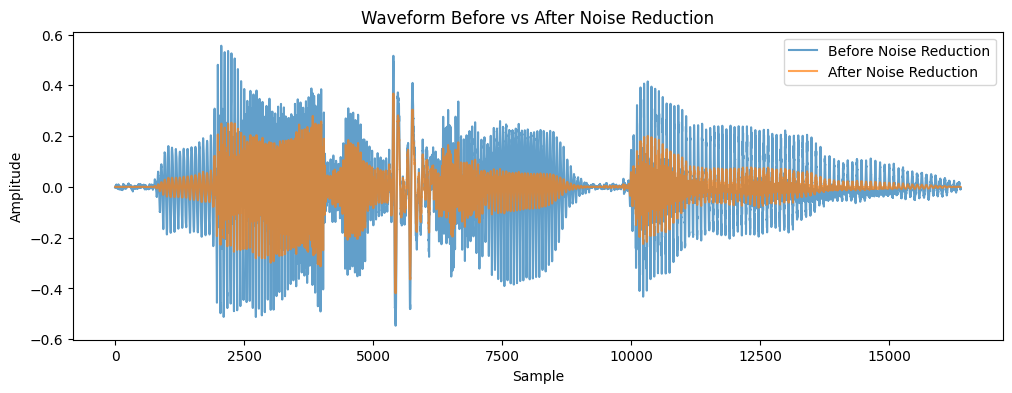

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(signal_trimmed[1], label='Before Noise Reduction', alpha=0.7)
plt.plot(signal_clean[1], label='After Noise Reduction', alpha=0.7)
plt.legend()
plt.title("Waveform Before vs After Noise Reduction")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
#normalisasi
signal_normalized = []
for i in range(len(signal_clean)):
  y_norm = signal_clean[i] / max(abs(signal_clean[i]))
  signal_normalized.append(y_norm)

Visualisasi setelah normalisasi


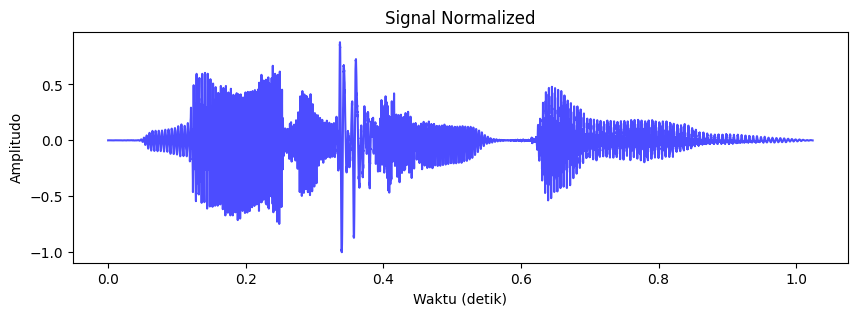

In [ ]:
print("Visualisasi setelah normalisasi")
time = np.linspace(0, len(signal_normalized[1]) / sr, num=len(signal_normalized[1]))

plt.figure(figsize=(10, 3)) # Ukuran plot
plt.plot(time, signal_normalized[1], color='blue', alpha=0.7) # Plot sinyal
plt.title('Signal Normalized') # Judul
plt.xlabel('Waktu (detik)') # Label sumbu X
plt.ylabel('Amplitudo') # Label sumbu Y
plt.show() # Tampilkan plot

In [ ]:
#pre-emphasis
signal_preemphasized = []
for i in range(len(signal_normalized)):
  y_preemphasized = np.append(signal_normalized[i][0], signal_normalized[i][1:] - 0.97 * signal_trimmed[i][:-1])
  signal_preemphasized.append(y_preemphasized)

Visualisasi Pre-emphasis


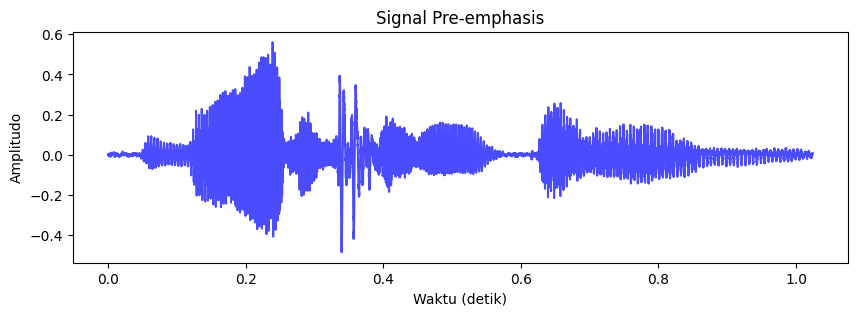

In [ ]:
print("Visualisasi Pre-emphasis")
time = np.linspace(0, len(signal_preemphasized[1]) / sr, num=len(signal_preemphasized[1]))

plt.figure(figsize=(10, 3)) # Ukuran plot
plt.plot(time, signal_preemphasized[1], color='blue', alpha=0.7) # Plot sinyal
plt.title('Signal Pre-emphasis') # Judul
plt.xlabel('Waktu (detik)') # Label sumbu X
plt.ylabel('Amplitudo') # Label sumbu Y
plt.show() # Tampilkan plot

In [ ]:
#penasaran, mau lihat outputnya gimana sih

from IPython.display import Audio, display

print("Sinyal asli:")
display(Audio(data=sinyal_1d[1], rate=sample_rate[1]))

print("Sinyal setelah trimming:")
display(Audio(data=signal_trimmed[1], rate=sample_rate[1]))

print("Sinyal setelah noise reduction:")
display(Audio(data=signal_clean[1], rate=sample_rate[1]))

print("Sinyal setelah normalisasi:")
display(Audio(data=signal_normalized[1], rate=sample_rate[1]))

print("Sinyal hasil pre-emphasis:")
display(Audio(data=signal_preemphasized[1], rate=sample_rate[1]))

Sinyal asli:


Sinyal setelah trimming:


Sinyal setelah noise reduction:


Sinyal setelah normalisasi:


Sinyal hasil pre-emphasis:


#Frame Blocking

In [ ]:
#membagi sinyal menjadi potongan kecil yang saling overlapping (tumpang tindih)

frame_length_ms = 25 #durasi potongan yang dianalisis
frame_step_ms = 10 #pergeseran jendela ke sinyal berikut
#sehingga besar overlap yang akan terjadi 25 - 10 = 15
#harus overlapping supaya tidak kehilangan informasi yang penting

list_frame_blocking = []
for i in range(len(signal_preemphasized)):
  frame_length = int(frame_length_ms / 1000 * sample_rate[i])
  frame_step = int(frame_step_ms / 1000 * sample_rate[i])
  frames = librosa.util.frame(signal_preemphasized[i],
                              frame_length=frame_length,
                              hop_length=frame_step)
  list_frame_blocking.append(frames)

In [ ]:
print(f"Sample Rate (asumsi): {sample_rate[0]} Hz")
print(f"Frame Length: {frame_length_ms} ms = {frame_length} sampel")
print(f"Frame Step (Hop): {frame_step_ms} ms = {frame_step} sampel")

print(f"\nBentuk sinyal asli (contoh 1): {signal_preemphasized[0].shape}")
print(f"Bentuk setelah framing (contoh 1): {list_frame_blocking[0].shape}")

Sample Rate (asumsi): 16000 Hz
Frame Length: 25 ms = 400 sampel
Frame Step (Hop): 10 ms = 160 sampel

Bentuk sinyal asli (contoh 1): (13312,)
Bentuk setelah framing (contoh 1): (400, 81)


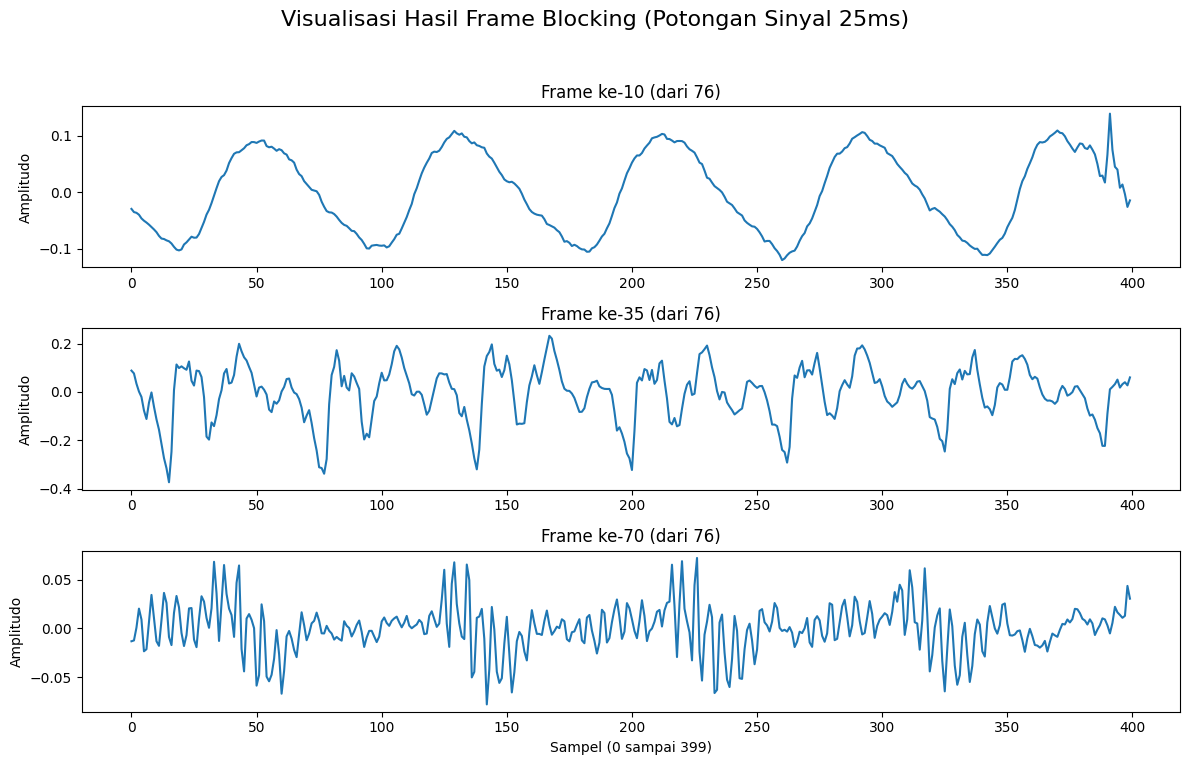

In [ ]:
frames_contoh = list_frame_blocking[0]

x_axis = np.arange(frame_length)

# --- Mulai Plotting ---
plt.figure(figsize=(12, 8))
plt.suptitle('Visualisasi Hasil Frame Blocking (Potongan Sinyal 25ms)', fontsize=16)

# 1. Plot frame dari bagian awal (misal: frame ke-10)
plt.subplot(3, 1, 1) # 3 baris, 1 kolom, plot ke-1
plt.plot(x_axis, frames_contoh[:, 10]) # Ambil semua baris di kolom ke-10
plt.title('Frame ke-10 (dari 76)')
plt.ylabel('Amplitudo')

# 2. Plot frame dari bagian tengah (misal: frame ke-35)
plt.subplot(3, 1, 2) # Plot ke-2
plt.plot(x_axis, frames_contoh[:, 35]) # Ambil semua baris di kolom ke-35
plt.title('Frame ke-35 (dari 76)')
plt.ylabel('Amplitudo')

# 3. Plot frame dari bagian akhir (misal: frame ke-70)
plt.subplot(3, 1, 3) # Plot ke-3
plt.plot(x_axis, frames_contoh[:, 70]) # Ambil semua baris di kolom ke-70
plt.title('Frame ke-70 (dari 76)')
plt.ylabel('Amplitudo')
plt.xlabel('Sampel (0 sampai 399)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Atur layout
plt.show()

#Windowing

In [ ]:
#menggunakan hamming window
#menerapkan filter ke setiap frame yang sudah dipotong
#karena tepi yang dihasilkan tajam dan bisa menyebabkan noise

hamming_window = librosa.filters.get_window('hamming',
                                            frame_length)

list_windowed_frames = []
for i in  range(len(list_frame_blocking)):
  windowed_frames = list_frame_blocking[i] * hamming_window[:, np.newaxis]
  list_windowed_frames.append(windowed_frames)

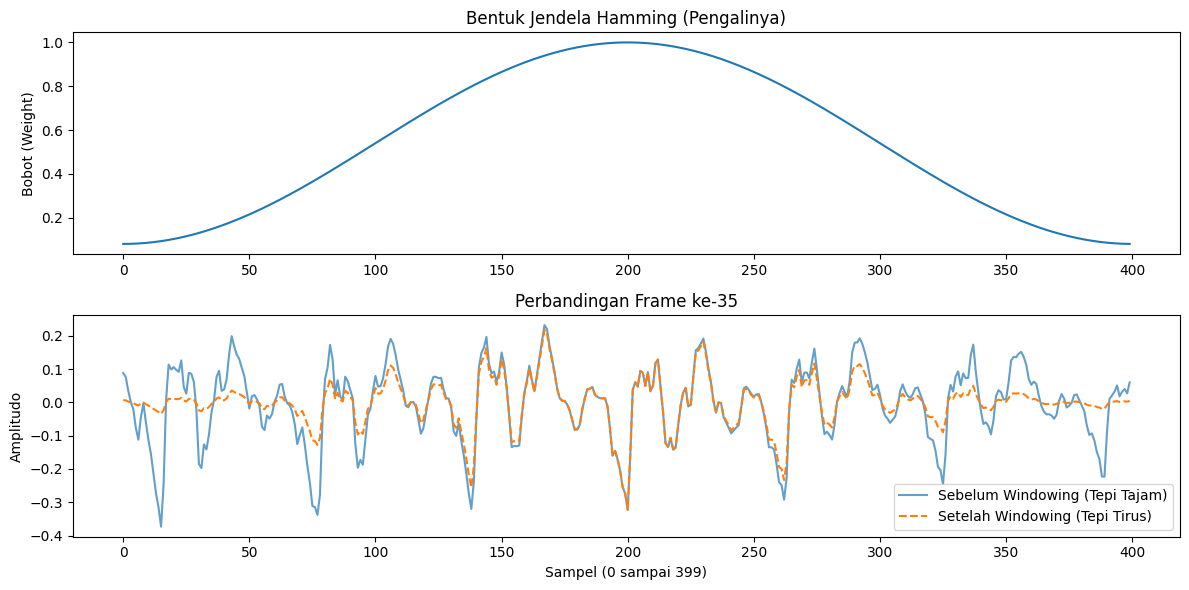

In [ ]:
plt.figure(figsize=(12, 6))

# Plot 1: Bentuk Jendela Hamming
plt.subplot(2, 1, 1)
plt.plot(hamming_window)
plt.title("Bentuk Jendela Hamming (Pengalinya)")
plt.ylabel("Bobot (Weight)")

# Plot 2: Perbandingan frame
frame_sebelum = list_frame_blocking[0][:, 35]
frame_sesudah = list_windowed_frames[0][:, 35]
x_axis = np.arange(frame_length)

plt.subplot(2, 1, 2)
plt.plot(x_axis, frame_sebelum, label='Sebelum Windowing (Tepi Tajam)', alpha=0.7)
plt.plot(x_axis, frame_sesudah, label='Setelah Windowing (Tepi Tirus)', linestyle='--')
plt.title("Perbandingan Frame ke-35")
plt.xlabel(f"Sampel (0 sampai {frame_length-1})")
plt.ylabel("Amplitudo")
plt.legend()
plt.tight_layout()
plt.show()

#Fast Fourier Transform (FFT)

In [ ]:
#untuk convert tiap frame dari domain waktu ke domain frekuensi
#dengan output berupa spectrum setiap frame
#menampilkan magnitude komponen frekuensi yang berbeda-beda dalam short segment of audio

# 1. Tentukan parameter FFT
# Ambil pangkat 2 berikutnya setelah frame_length_samples
n_fft = 2048

list_power_spectrum = [] # List untuk menampung hasil

print("--- Memulai FFT (Konversi ke Domain Frekuensi) ---")

# Loop melalui semua 25 sinyal yang sudah di-windowing
for i in range(len(list_windowed_frames)):
  # 2. Terapkan FFT
  # Kita terapkan FFT pada setiap kolom (axis=0)
  # n=n_fft akan otomatis menambahkan padding ke 2048
  fft_result_complex = np.fft.rfft(list_windowed_frames[i], n=n_fft, axis=0)

  # 3. Hitung Power Spectrum
  # Hasil FFT adalah angka kompleks. Kita ambil besaran (magnitude)
  # lalu kuadratkan untuk mendapatkan "Power Spectrum" (energi)
  power_spectrum = np.abs(fft_result_complex) ** 2

  # 4. Simpan hasilnya
  list_power_spectrum.append(power_spectrum)

print("--- FFT Selesai ---")

# --- Mari kita cek hasilnya ---
print(f"n_fft (Resolusi FFT): {n_fft}")
print("\n--- Perubahan Bentuk (Shape) Data ---")
print(f"Bentuk setelah windowing (contoh 1): {list_windowed_frames[0].shape}")
print(f"Bentuk setelah FFT (contoh 1): {list_power_spectrum[0].shape}")

--- Memulai FFT (Konversi ke Domain Frekuensi) ---
--- FFT Selesai ---
n_fft (Resolusi FFT): 2048

--- Perubahan Bentuk (Shape) Data ---
Bentuk setelah windowing (contoh 1): (400, 81)
Bentuk setelah FFT (contoh 1): (1025, 81)


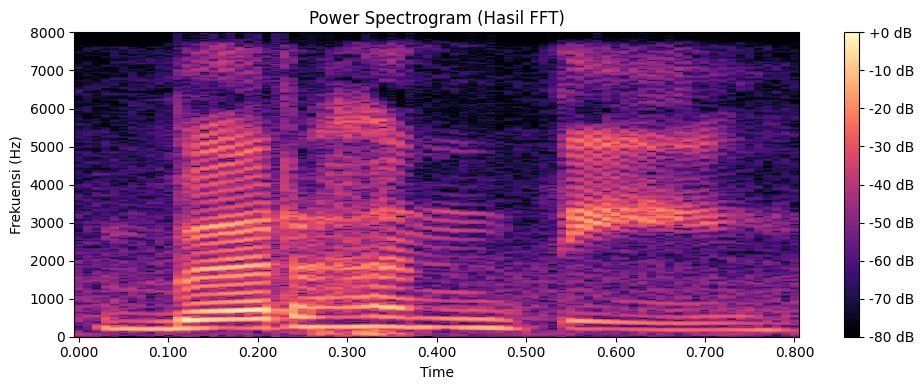

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- Asumsi dari langkah sebelumnya ---
# list_power_spectrum: List berisi 25 array 2D (shape (1025, 76))
# sample_rate: List berisi 25 sample rate (misal: 48000)
# frame_step_samples: Ukuran hop Anda (misal: 480)

# 1. Ambil satu contoh spectrogram untuk diplot
power_spec_contoh = list_power_spectrum[0] # Shape (1025, 76)
sr_contoh = sample_rate[0]

# 2. Konversi Power ke skala Desibel (dB)
# Ini membuat visualisasinya jauh lebih jelas
spec_db = librosa.power_to_db(power_spec_contoh, ref=np.max)

# --- Mulai Plotting ---
plt.figure(figsize=(10, 4))

# 3. Gunakan librosa.display.specshow
librosa.display.specshow(spec_db,
                         sr=sr_contoh,
                         hop_length=frame_step,
                         x_axis='time',
                         y_axis='linear') # 'linear' menunjukkan frekuensi 0-Nyquist

plt.colorbar(format='%+2.0f dB') # Menambahkan bar warna
plt.title('Power Spectrogram (Hasil FFT)')
plt.ylabel('Frekuensi (Hz)')
plt.tight_layout()
plt.show()

#Mel Filter Bank

--- Menerapkan Mel Filterbank ---
--- Mel Filterbank Selesai ---
Jumlah Filter Mel (n_mels): 40
Bentuk 'Cetakan' Mel Filterbank: (40, 1025)

--- Perubahan Bentuk (Shape) Data ---
Bentuk Power Spectrogram (contoh 1): (1025, 81)
Bentuk Mel Spectrogram (contoh 1): (40, 81)


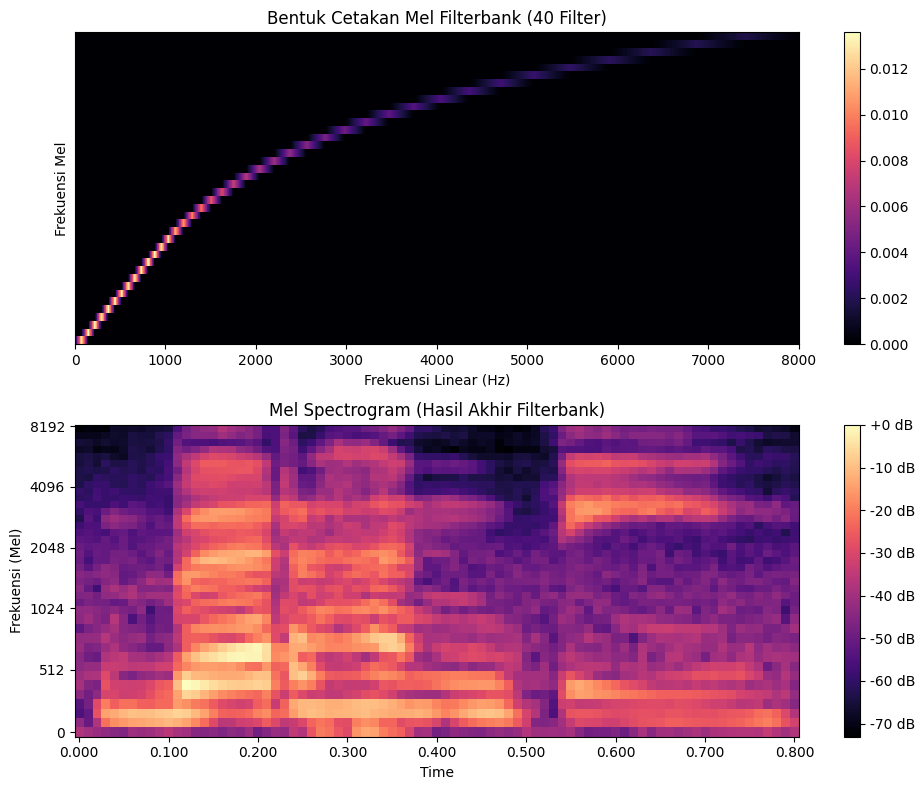

In [ ]:
#menirukan pendengaran manusia

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# 1. Tentukan parameter Mel
n_mels = 40

# Ambil SR dari data pertama (asumsi semua SR sama)
sr_referensi = sample_rate[0]

# 2. Buat "Cetakan" Mel Filterbank
mel_filters = librosa.filters.mel(sr=sr_referensi,
                                  n_fft=n_fft,
                                  n_mels=n_mels)

list_mel_spectrograms = [] # List untuk menampung hasil

print("--- Menerapkan Mel Filterbank ---")

# Loop melalui semua 25 power spectrum
for power_spec in list_power_spectrum:
  # 3. Terapkan filterbank (ini adalah intinya: Matrix Multiplication)
  mel_spectrogram = np.dot(mel_filters, power_spec)
  list_mel_spectrograms.append(mel_spectrogram)
print("--- Mel Filterbank Selesai ---")

# --- Mari kita cek hasilnya ---
print(f"Jumlah Filter Mel (n_mels): {n_mels}")
print(f"Bentuk 'Cetakan' Mel Filterbank: {mel_filters.shape}")
print("\n--- Perubahan Bentuk (Shape) Data ---")
print(f"Bentuk Power Spectrogram (contoh 1): {list_power_spectrum[0].shape}")
print(f"Bentuk Mel Spectrogram (contoh 1): {list_mel_spectrograms[0].shape}")

# --- VISUALISASI ---
plt.figure(figsize=(10, 8))

# Plot 1: Visualisasi bentuk "cetakan" filterbank
plt.subplot(2, 1, 1)
librosa.display.specshow(mel_filters,
                         sr=sr_referensi,
                         x_axis='linear')
plt.title('Bentuk Cetakan Mel Filterbank (40 Filter)')
plt.ylabel('Frekuensi Mel')
plt.xlabel('Frekuensi Linear (Hz)')
plt.colorbar()

# Plot 2: Visualisasi Mel Spectrogram (hasil akhirnya)
# Ambil satu contoh dan ubah ke dB
mel_spec_contoh = list_mel_spectrograms[0]
mel_spec_db = librosa.power_to_db(mel_spec_contoh, ref=np.max)

plt.subplot(2, 1, 2)
librosa.display.specshow(mel_spec_db,
                         sr=sr_referensi,
                         hop_length=frame_step,
                         x_axis='time',
                         y_axis='mel') # <-- Sumbu Y sekarang 'mel'
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram (Hasil Akhir Filterbank)')
plt.ylabel('Frekuensi (Mel)')
plt.tight_layout()
plt.show()

#Log Energy

In [ ]:
import librosa
import numpy as np

list_log_spectrograms = []

print("--- Memulai Langkah 6a: Log Energy ---")

for mel_spec in list_mel_spectrograms:
  # Ambil Log Energy (konversi ke dB)
  log_mel_spec = librosa.power_to_db(mel_spec)
  list_log_spectrograms.append(log_mel_spec)

print("--- Log Energy Selesai ---")
print(f"Bentuk Mel Spectrogram (contoh 1): {list_mel_spectrograms[0].shape}")
print(f"Bentuk Log Mel Spectrogram (contoh 1): {list_log_spectrograms[0].shape}")
print("Bentuknya tetap sama, hanya nilainya yang berubah (sekarang dalam dB).")

--- Memulai Langkah 6a: Log Energy ---
--- Log Energy Selesai ---
Bentuk Mel Spectrogram (contoh 1): (40, 81)
Bentuk Log Mel Spectrogram (contoh 1): (40, 81)
Bentuknya tetap sama, hanya nilainya yang berubah (sekarang dalam dB).


#Discrete Cosine Transform

In [ ]:
from scipy.fftpack import dct

list_dct_results = []
print("--- Memulai Langkah 6b: Discrete Cosine Transform (DCT) ---")

for log_mel_spec in list_log_spectrograms:
  dct_result = dct(log_mel_spec, type=2, axis=0, norm='ortho')
  list_dct_results.append(dct_result)

print("--- DCT Selesai ---")
print(f"Bentuk Log Mel Spectrogram (contoh 1): {list_log_spectrograms[0].shape}")
print(f"Bentuk setelah DCT (Cepstrum) (contoh 1): {list_dct_results[0].shape}")
print("Bentuknya MASIH SAMA (40, 76).")

--- Memulai Langkah 6b: Discrete Cosine Transform (DCT) ---
--- DCT Selesai ---
Bentuk Log Mel Spectrogram (contoh 1): (40, 81)
Bentuk setelah DCT (Cepstrum) (contoh 1): (40, 81)
Bentuknya MASIH SAMA (40, 76).


#Final MFCCs

In [ ]:
n_mfcc = 13 # Jumlah koefisien yang ingin kita simpan

list_mfccs = []
print(f"--- Memulai Langkah 6c: Memangkas menjadi {n_mfcc} MFCCs ---")

for dct_result in list_dct_results:
  #Ambil hanya 'n_mfcc' baris pertama
  mfcc_pruned = dct_result[:n_mfcc, :]

  list_mfccs.append(mfcc_pruned)

print("--- MFCC Selesai Dibuat ---")
print(f"Bentuk setelah DCT (contoh 1): {list_dct_results[0].shape}")
print(f"Bentuk setelah dipangkas (MFCC) (contoh 1): {list_mfccs[0].shape}")

--- Memulai Langkah 6c: Memangkas menjadi 13 MFCCs ---
--- MFCC Selesai Dibuat ---
Bentuk setelah DCT (contoh 1): (40, 81)
Bentuk setelah dipangkas (MFCC) (contoh 1): (13, 81)


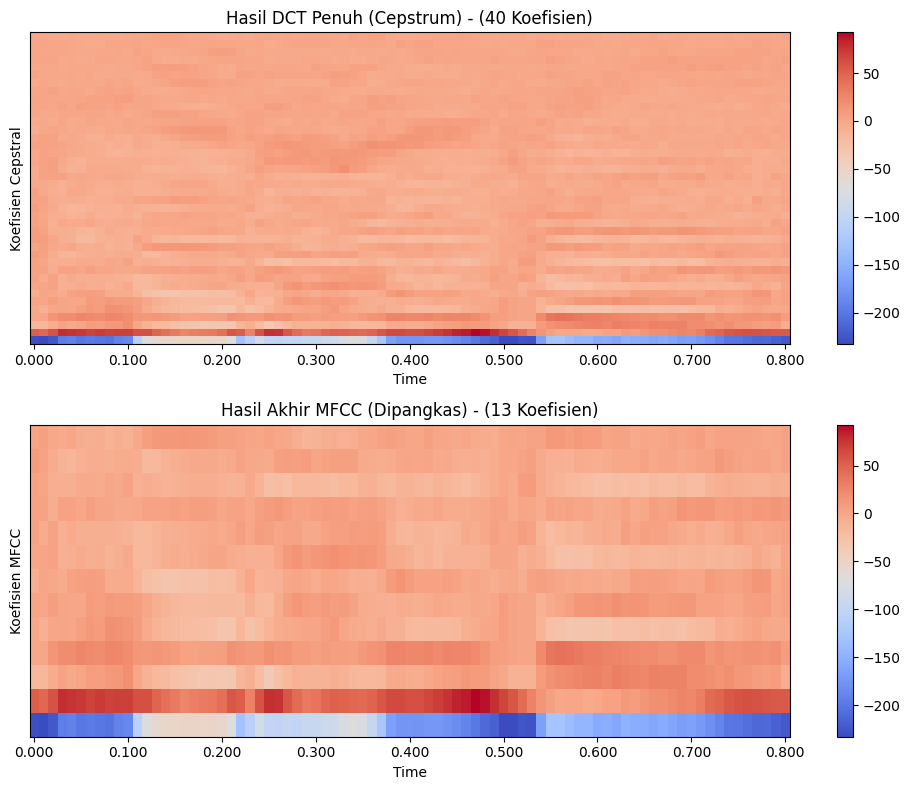

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# Ambil satu contoh
dct_contoh = list_dct_results[0]
mfcc_contoh = list_mfccs[0]

# Asumsi dari data sebelumnya
sr_contoh = sample_rate[0]
frame_step_samples = int(10 / 1000 * sr_contoh) # 10 ms hop

plt.figure(figsize=(10, 8))

# Plot 1: Hasil DCT penuh (Cepstrum)
plt.subplot(2, 1, 1)
librosa.display.specshow(dct_contoh,
                         sr=sr_contoh,
                         hop_length=frame_step_samples,
                         x_axis='time')
plt.title('Hasil DCT Penuh (Cepstrum) - (40 Koefisien)')
plt.ylabel('Koefisien Cepstral')
plt.colorbar()

# Plot 2: Hasil MFCC (setelah dipangkas)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfcc_contoh,
                         sr=sr_contoh,
                         hop_length=frame_step_samples,
                         x_axis='time')
plt.title(f'Hasil Akhir MFCC (Dipangkas) - ({n_mfcc} Koefisien)')
plt.ylabel('Koefisien MFCC')
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
print(len(list_mfccs))

125


In [ ]:
import os

data_mfccs = []

for i, mfcc in enumerate(list_mfccs):
  file_name = os.path.basename(records[i])  # ambil nama file-nya aja
  data_mfccs.append({
      'file': file_name,
      'mfcc': mfcc
  })

# Cek contoh hasilnya
for d in data_mfccs[:5]:
  print(d['file'], d['mfcc'].shape)

Berhenti 1.m4a (13, 81)
Berhenti 2.m4a (13, 100)
Berhenti 3.m4a (13, 97)
Berhenti 4.m4a (13, 104)
Berhenti 5.m4a (13, 104)


In [ ]:
print(len(data_mfccs))

125


In [ ]:
# Ambil salah satu contoh MFCC
mfcc_example = list_mfccs[0]  # atau data_mfccs[0]['mfcc']

# Konversi balik ke audio perkiraan
audio_reconstructed = librosa.feature.inverse.mfcc_to_audio(mfcc_example, sr=sample_rate[0])

# Putar hasilnya
display(Audio(audio_reconstructed, rate=sample_rate[0]))

#Buat template database

In [1]:
def normalize_mfcc_length(mfcc, target_len=80):
  if mfcc.shape[1] > target_len:
    return mfcc[:, :target_len]
  else:
    pad_width = target_len - mfcc.shape[1]
    return np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')

In [ ]:
import os, re

template_database = []

for item in data_mfccs:
  fname = item['file']
  mfcc_feat = item['mfcc']
  mfcc_norm = normalize_mfcc_length(mfcc_feat)

  # Ambil nama file tanpa path
  basename = os.path.basename(fname)
  # Bersihin jadi huruf kecil tanpa spasi/angka/tanda baca
  fname_clean = re.sub(r'[^a-z]', '', basename.lower())

  # Deteksi label berdasar nama file
  if 'maju' in fname_clean:
    label = 'maju'
  elif 'mundur' in fname_clean:
    label = 'mundur'
  elif 'berhenti' in fname_clean:
    label = 'berhenti'
  elif 'kiri' in fname_clean:
    label = 'kiri'
  elif 'kanan' in fname_clean:
    label = 'kanan'
  else:
    print(f"⚠️ File {basename} dilewati karena tidak dikenali labelnya.")
    continue

  template_database.append((label, mfcc_norm))

print(f"✅ Template database siap: {len(template_database)} data MFCC")


✅ Template database siap: 125 data MFCC


In [ ]:
#cek banyak data sesuai label
from collections import Counter
print(Counter([lbl for lbl, _ in template_database]))

Counter({'berhenti': 25, 'kanan': 25, 'kiri': 25, 'maju': 25, 'mundur': 25})


In [ ]:
# debugging: cek distribusi label + contoh shapes
from collections import Counter
import pprint

labels = [lbl for lbl, mfcc in template_database]
print("Distribusi label (template_database):")
pprint.pprint(Counter(labels))

# tampilkan 5 contoh per label (shape)
by_label = {}
for lbl, mfcc in template_database:
  by_label.setdefault(lbl, []).append(mfcc)

for lbl, lst in by_label.items():
  print(f"\nLabel {lbl}: {len(lst)} contoh, contoh shape (first): {lst[0].shape if len(lst)>0 else None}")

Distribusi label (template_database):
Counter({'berhenti': 25, 'kanan': 25, 'kiri': 25, 'maju': 25, 'mundur': 25})

Label berhenti: 25 contoh, contoh shape (first): (13, 80)

Label kanan: 25 contoh, contoh shape (first): (13, 80)

Label kiri: 25 contoh, contoh shape (first): (13, 80)

Label maju: 25 contoh, contoh shape (first): (13, 80)

Label mundur: 25 contoh, contoh shape (first): (13, 80)


In [ ]:
!pip install dtw-python
!pip install SpeechRecognition
!apt-get install -y portaudio19-dev
!pip install PyAudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 29.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libportaudio2 libportaudiocpp0
Suggested packages:
  portaudio19-doc
The following NEW packages will be installed:
  libportaudio2 libportaudiocpp0 portaudio19-dev
0 upgraded, 3 newly installed, 0 to remove and 38 not upgraded.
Need to get 188 kB of archives.
After this operation, 927 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudiocpp0 amd64 19.6.0-1.1 [16.1 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 portaudio19-dev amd64 19.6.0-1.1 [106 kB]
Fetched 188 kB in 1s (277 kB/s)
Selecting previously u

#Pengujian

In [ ]:
# ===========================================
# 5️⃣ TESTING (REKAM SUARA LANGSUNG)
# ===========================================
from IPython.display import HTML, display
from google.colab.output import eval_js
from base64 import b64decode
import time
from dtw import dtw
from collections import Counter

AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_btn = document.createElement("BUTTON");
var t = document.createTextNode("Tekan untuk Mulai Merekam");
my_btn.appendChild(t); my_div.appendChild(my_btn); document.body.appendChild(my_div);
var base64data = 0; var reader; var recorder, gumStream;
var handleSuccess = function(stream) {
  gumStream = stream;
  recorder = new MediaRecorder(stream, {mimeType : 'audio/webm;codecs=opus'});
  recorder.ondataavailable = function(e) {
    var url = URL.createObjectURL(e.data);
    var preview = document.createElement('audio');
    preview.controls = true; preview.src = url; document.body.appendChild(preview);
    reader = new FileReader();
    reader.readAsDataURL(e.data);
    reader.onloadend = function() { base64data = reader.result; }
  };
  recorder.start();
  my_btn.innerText = "🔴 Merekam...";
};
navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess);
function toggleRecording() {
  if (recorder && recorder.state == "recording") {
    recorder.stop(); gumStream.getAudioTracks()[0].stop();
    my_btn.innerText = "Proses Selesai, audio dikirim..."
  }
}
setTimeout(toggleRecording, 5000);
</script>
"""

def get_audio():
  display(HTML(AUDIO_HTML))
  print("🎙️ Rekam suara (5 detik)...")
  time.sleep(6)
  base64_data = eval_js("base64data")
  _, data_string = base64_data.split(',')
  audio_bytes = b64decode(data_string)
  process = (ffmpeg.input('pipe:0')
              .output('pipe:1', format='wav', acodec='pcm_s16le')
              .run_async(pipe_stdin=True, pipe_stdout=True, pipe_stderr=True, quiet=True))
  wav_bytes, _ = process.communicate(input=audio_bytes)
  return wav_bytes

def preprocessing(sinyal, top_db=30, pre_emphasis=0.97):
  sinyal_trimmed, _ = librosa.effects.trim(sinyal, top_db=top_db)
  sinyal_preemphasized = np.append(sinyal_trimmed[0], sinyal_trimmed[1:] - pre_emphasis * sinyal_trimmed[:-1])
  return sinyal_preemphasized

from scipy.fftpack import dct

FRAME_LENGTH_MS = 25
FRAME_STEP_MS = 10
N_FFT = 2048
N_MELS = 40
N_MFCC = 13
SR_REFERENSI = 48000

FRAME_LENGTH_SAMPLES = int(FRAME_LENGTH_MS / 1000 * SR_REFERENSI)
FRAME_STEP_SAMPLES = int(FRAME_STEP_MS / 1000 * SR_REFERENSI)

HAMMING_WINDOW = librosa.filters.get_window('hamming', FRAME_LENGTH_SAMPLES)
MEL_FILTERS = librosa.filters.mel(sr=SR_REFERENSI, n_fft=N_FFT, n_mels=N_MELS)

def ekstraksi_mfcc(sinyal):
  frames = librosa.util.frame(sinyal, frame_length=FRAME_LENGTH_SAMPLES, hop_length=FRAME_STEP_SAMPLES)
  windowed = frames * HAMMING_WINDOW[:, np.newaxis]
  fft_result = np.fft.rfft(windowed, n=N_FFT, axis=0)
  power_spec = np.abs(fft_result) ** 2
  mel_spec = np.dot(MEL_FILTERS, power_spec)
  log_mel_spec = librosa.power_to_db(mel_spec)
  mfcc = dct(log_mel_spec, type=2, axis=0, norm='ortho')[:N_MFCC, :]
  return mfcc

def proses_audio_ke_mfcc(wav_bytes):
  y, sr = librosa.load(io.BytesIO(wav_bytes), sr=SR_REFERENSI)
  y_proc = preprocessing(y)
  return ekstraksi_mfcc(y_proc)

def kenali_perintah(template_db):
  wav_data = get_audio()
  mfcc_baru = proses_audio_ke_mfcc(wav_data).T
  list_jarak = []

  for label, mfcc_template in template_db:
    alignment = dtw(mfcc_baru, mfcc_template.T, keep_internals=False)
    # 🔥 Normalisasi jarak biar gak bias ke durasi pendek
    jarak_norm = alignment.distance / max(len(mfcc_baru), len(mfcc_template.T))
    list_jarak.append((label, jarak_norm))

  list_jarak.sort(key=lambda x: x[1])
  k = 5  # pakai 5 biar voting lebih stabil
  top_k = list_jarak[:k]

  print(f"\n--- {k} Template Terdekat ---")
  for lbl, jarak in top_k:
    print(f"  Label: {lbl} (Jarak: {jarak:.2f})")

  label_terdekat = [lbl for lbl, _ in top_k]
  hasil_voting = Counter(label_terdekat).most_common(1)[0][0]

  return hasil_voting

In [ ]:
#Mundur
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: mundur (Jarak: 87.70)
  Label: maju (Jarak: 104.99)
  Label: kanan (Jarak: 105.09)
  Label: mundur (Jarak: 109.46)
  Label: berhenti (Jarak: 110.00)
🔥 Hasil prediksi: MUNDUR


In [ ]:
#Kiri
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: kiri (Jarak: 62.81)
  Label: kiri (Jarak: 67.42)
  Label: mundur (Jarak: 79.31)
  Label: kiri (Jarak: 79.52)
  Label: mundur (Jarak: 81.59)
🔥 Hasil prediksi: KIRI


In [ ]:
#Kiri
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: kiri (Jarak: 75.03)
  Label: kiri (Jarak: 83.61)
  Label: kiri (Jarak: 85.54)
  Label: berhenti (Jarak: 85.75)
  Label: kiri (Jarak: 85.81)
🔥 Hasil prediksi: KIRI


In [ ]:
#Berhenti
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: kiri (Jarak: 84.96)
  Label: berhenti (Jarak: 87.06)
  Label: berhenti (Jarak: 87.18)
  Label: kanan (Jarak: 90.94)
  Label: berhenti (Jarak: 92.33)
🔥 Hasil prediksi: BERHENTI


In [ ]:
#Mundur
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: mundur (Jarak: 93.06)
  Label: maju (Jarak: 106.83)
  Label: kanan (Jarak: 111.37)
  Label: berhenti (Jarak: 116.98)
  Label: mundur (Jarak: 119.18)
🔥 Hasil prediksi: MUNDUR


In [ ]:
#Kiri
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: kiri (Jarak: 70.77)
  Label: kiri (Jarak: 78.68)
  Label: berhenti (Jarak: 91.34)
  Label: berhenti (Jarak: 93.46)
  Label: kiri (Jarak: 95.72)
🔥 Hasil prediksi: KIRI


In [ ]:
#Kanan
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: kanan (Jarak: 89.55)
  Label: berhenti (Jarak: 91.25)
  Label: maju (Jarak: 92.98)
  Label: maju (Jarak: 93.51)
  Label: kanan (Jarak: 94.79)
🔥 Hasil prediksi: KANAN


In [ ]:
#Berhenti
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: berhenti (Jarak: 126.24)
  Label: berhenti (Jarak: 134.00)
  Label: berhenti (Jarak: 134.70)
  Label: maju (Jarak: 140.05)
  Label: mundur (Jarak: 147.29)
🔥 Hasil prediksi: BERHENTI


In [ ]:
#Mundur
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: mundur (Jarak: 79.91)
  Label: mundur (Jarak: 86.72)
  Label: maju (Jarak: 90.41)
  Label: berhenti (Jarak: 93.92)
  Label: maju (Jarak: 97.52)
🔥 Hasil prediksi: MUNDUR


In [ ]:
#Maju
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: maju (Jarak: 64.48)
  Label: maju (Jarak: 76.94)
  Label: maju (Jarak: 81.64)
  Label: mundur (Jarak: 81.75)
  Label: berhenti (Jarak: 85.59)
🔥 Hasil prediksi: MAJU


In [ ]:
#Mundur
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: mundur (Jarak: 88.20)
  Label: kanan (Jarak: 100.21)
  Label: maju (Jarak: 103.45)
  Label: berhenti (Jarak: 104.78)
  Label: mundur (Jarak: 106.99)
🔥 Hasil prediksi: MUNDUR


In [ ]:
#Berhenti
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: berhenti (Jarak: 102.41)
  Label: berhenti (Jarak: 102.83)
  Label: berhenti (Jarak: 105.24)
  Label: berhenti (Jarak: 105.99)
  Label: berhenti (Jarak: 112.11)
🔥 Hasil prediksi: BERHENTI


In [ ]:
#Mundur
print("===== UJI SISTEM PENGENALAN SUARA =====")
hasil = kenali_perintah(template_database)
print(f"🔥 Hasil prediksi: {hasil.upper()}")

===== UJI SISTEM PENGENALAN SUARA =====


🎙️ Rekam suara (5 detik)...

--- 5 Template Terdekat ---
  Label: mundur (Jarak: 116.57)
  Label: maju (Jarak: 125.02)
  Label: mundur (Jarak: 125.30)
  Label: mundur (Jarak: 129.41)
  Label: berhenti (Jarak: 134.78)
🔥 Hasil prediksi: MUNDUR


#Hitung akurasi

In [ ]:
from collections import Counter
import numpy as np
import re, os
from dtw import dtw

def prediksi_perintah(mfcc_test, template_db):
  list_jarak = []
  for label, mfcc_template in template_db:
      jarak = dtw(mfcc_test.T, mfcc_template.T).distance
      list_jarak.append((label, jarak))
  list_jarak.sort(key=lambda x: x[1])
  return list_jarak[0][0]  # ambil label jarak terdekat
# --- Evaluasi ---
benar = 0
total = 0
hasil_detail = []

for item in data_mfccs:
  fname = os.path.basename(item['file'])
  mfcc_test = item['mfcc']

  # Ambil label dari nama file (kayak sebelumnya)
  fname_clean = re.sub(r'[^a-z]', '', fname.lower())
  if 'maju' in fname_clean:
    label_asli = 'maju'
  elif 'mundur' in fname_clean:
    label_asli = 'mundur'
  elif 'berhenti' in fname_clean:
    label_asli = 'berhenti'
  elif 'kiri' in fname_clean:
    label_asli = 'kiri'
  elif 'kanan' in fname_clean:
    label_asli = 'kanan'
  else:
    continue  # skip kalau nama aneh

  prediksi = prediksi_perintah(mfcc_test, template_database)
  benar += (prediksi == label_asli)
  total += 1
  hasil_detail.append((fname, label_asli, prediksi))

akurasi = benar / total * 100
print(f"\n✅ Akurasi Training: {akurasi:.2f}% ({benar}/{total} benar)")

# --- (opsional) tampilkan beberapa hasil ---
for f, y_true, y_pred in hasil_detail[:10]:
  print(f"{f:25s} | Asli: {y_true:9s} | Prediksi: {y_pred}")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.


✅ Akurasi Training: 98.40% (123/125 benar)
Berhenti 1.m4a            | Asli: berhenti  | Prediksi: berhenti
Berhenti 2.m4a            | Asli: berhenti  | Prediksi: berhenti
Berhenti 3.m4a            | Asli: berhenti  | Prediksi: berhenti
Berhenti 4.m4a            | Asli: berhenti  | Prediksi: berhenti
Berhenti 5.m4a            | Asli: berhenti  | Prediksi: berhenti
Kanan 1.m4a               | Asli: kanan     | Prediksi: kanan
Kanan 2.m4a               | Asli: kanan     | Prediksi: kanan
Kanan 3.m4a               | Asli: kanan     | Prediksi: kanan
Kanan 4.m4a               | Asli: kanan     | Prediksi: kanan
Kanan 5.m4a               | Asli: kanan     | Prediksi: kanan


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import librosa
import numpy as np
import re
from dtw import dtw

# Path
base_path = "/content/drive/MyDrive/Dataset_ASR"
test_path = os.path.join(base_path, "Testing")

# --- Fungsi bantu ---
def load_audio_m4a(file_path, target_sr=16000):
  """Load file .m4a dan ubah ke mono float32 di memori"""
  try:
      y, sr = librosa.load(file_path, sr=target_sr, mono=True)
      return y, sr
  except Exception as e:
      print(f"❌ Gagal baca {file_path}: {e}")
      return None, None

def extract_mfcc_from_signal(y, sr, n_mfcc=13):
  """Ekstraksi MFCC langsung dari sinyal"""
  try:
      mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
      return mfcc
  except Exception as e:
      print(f"❌ Gagal ekstrak MFCC: {e}")
      return None

def prediksi_perintah(mfcc_test, template_db):
  """Cocokkan MFCC test dengan template (DTW distance)"""
  list_jarak = []
  for label, mfcc_template in template_db:
      jarak = dtw(mfcc_test.T, mfcc_template.T).distance
      list_jarak.append((label, jarak))
  list_jarak.sort(key=lambda x: x[1])
  return list_jarak[0][0]

# --- Evaluasi ---
benar = 0
total = 0
hasil_detail = []

for fname in os.listdir(test_path):
  if not fname.endswith(".m4a"):
    continue

  file_path = os.path.join(test_path, fname)
  y, sr = load_audio_m4a(file_path)
  if y is None:
    continue

  mfcc_test = extract_mfcc_from_signal(y, sr)
  if mfcc_test is None:
    continue

  # Ambil label dari nama file
  fname_clean = re.sub(r'[^a-z]', '', fname.lower())
  if 'maju' in fname_clean:
    label_asli = 'maju'
  elif 'mundur' in fname_clean:
    label_asli = 'mundur'
  elif 'berhenti' in fname_clean:
    label_asli = 'berhenti'
  elif 'kiri' in fname_clean:
    label_asli = 'kiri'
  elif 'kanan' in fname_clean:
    label_asli = 'kanan'
  else:
    continue

  # Prediksi
  prediksi = prediksi_perintah(mfcc_test, template_database)
  benar += (prediksi == label_asli)
  total += 1
  hasil_detail.append((fname, label_asli, prediksi))

# --- Hasil ---
if total > 0:
  akurasi = benar / total * 100
  print(f"\n✅ Akurasi Testing: {akurasi:.2f}% ({benar}/{total} benar)")
else:
  print("\n⚠️ Tidak ada file valid untuk evaluasi!")

# --- (opsional) tampilkan beberapa hasil ---
for f, y_true, y_pred in hasil_detail[:10]:
  print(f"{f:25s} | Asli: {y_true:9s} | Prediksi: {y_pred}")


✅ Akurasi Testing: 80.00% (4/5 benar)
uji_berhenti.m4a          | Asli: berhenti  | Prediksi: berhenti
uji_kanan.m4a             | Asli: kanan     | Prediksi: kanan
uji_kiri.m4a              | Asli: kiri      | Prediksi: kiri
uji_mundur.m4a            | Asli: mundur    | Prediksi: berhenti
uji_maju.m4a              | Asli: maju      | Prediksi: maju


#Klasifikasi Machine Learning

In [ ]:
template_database

[('berhenti',
  array([[-2.30356321e+02, -2.31774610e+02, -2.23442742e+02, ...,
          -2.11479142e+02, -2.10259093e+02, -2.17327903e+02],
         [ 5.24467733e+01,  4.72970489e+01,  5.99785961e+01, ...,
           6.05475483e+01,  5.81358743e+01,  5.48298779e+01],
         [-1.75826829e+01, -1.53598390e+01, -5.18264791e+00, ...,
           7.51077703e+00,  4.99462532e+00,  8.39528336e+00],
         ...,
         [ 4.09907970e+00,  1.25979317e+00, -6.94132637e+00, ...,
          -1.03180699e+01, -9.44776989e+00, -6.12648458e+00],
         [ 8.68846547e+00,  3.42380351e+00, -5.02668506e+00, ...,
           3.39210726e+00,  4.42805585e+00, -4.30398554e-01],
         [ 2.02719507e+00,  5.01548142e+00, -1.28164248e+00, ...,
           1.94994351e+00, -7.53642896e-01,  2.11174945e-01]])),
 ('berhenti',
  array([[-2.36749567e+02, -2.40275490e+02, -2.39544791e+02, ...,
          -1.50532203e+02, -1.58010226e+02, -1.53777658e+02],
         [ 5.89780749e+01,  5.16782984e+01,  4.60031906e+01

In [ ]:
import numpy as np

x = []
y = []

for label, mfcc in template_database:
  # Ambil statistik sederhana dari MFCC
  mfcc_mean = np.mean(mfcc, axis=1)  # rata-rata tiap koefisien
  mfcc_std = np.std(mfcc, axis=1)    # simpangan baku tiap koefisien
  fitur = np.concatenate((mfcc_mean, mfcc_std))  # hasil: 26 elemen
  x.append(fitur)
  y.append(label)

x = np.array(x)

from sklearn.preprocessing import StandardScaler
x_scaled = StandardScaler().fit_transform(x)
y = np.array(y)

print("Shape fitur:", x.shape)
print("Jumlah label unik:", len(np.unique(y)))

Shape fitur: (125, 26)
Jumlah label unik: 5


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.1, stratify=y, random_state=29
)


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
params = {'C':[0.1, 1, 10], 'kernel':['linear', 'rbf'], 'gamma':['scale', 'auto']}
grid = GridSearchCV(SVC(kernel='rbf'), params, cv=3)
grid.fit(x_train, y_train)
print(grid.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred1 = grid.predict(x_test)
print("Akurasi:", accuracy_score(y_test, y_pred1) * 100, "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))


Akurasi: 92.3076923076923 %

Classification Report:
               precision    recall  f1-score   support

    berhenti       1.00      1.00      1.00         3
       kanan       1.00      0.67      0.80         3
        kiri       1.00      1.00      1.00         2
        maju       0.75      1.00      0.86         3
      mundur       1.00      1.00      1.00         2

    accuracy                           0.92        13
   macro avg       0.95      0.93      0.93        13
weighted avg       0.94      0.92      0.92        13


Confusion Matrix:
 [[3 0 0 0 0]
 [0 2 0 1 0]
 [0 0 2 0 0]
 [0 0 0 3 0]
 [0 0 0 0 2]]
